
i-band fit parameters
a = 1.41875462001044e-09
b = 0.6936961836457627


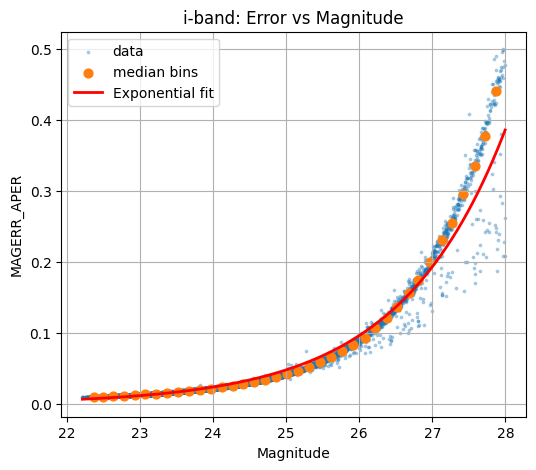


z-band fit parameters
a = 5.066766315299921e-10
b = 0.7396807970153849


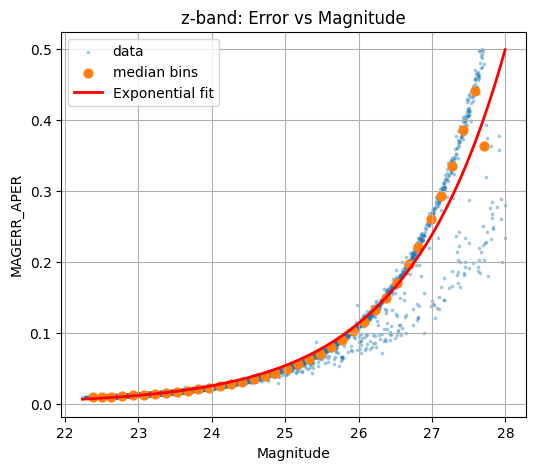


y-band fit parameters
a = 4.782827640177472e-10
b = 0.8399565100031879


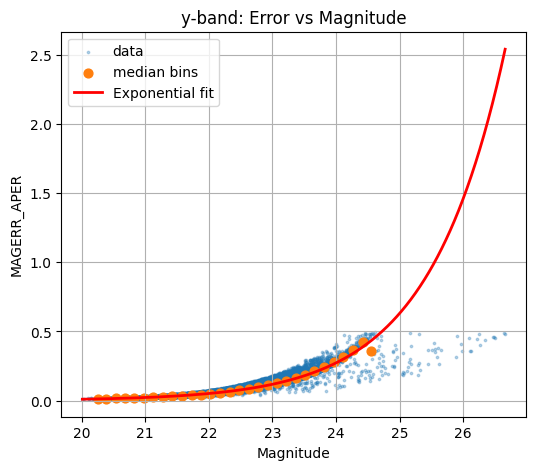

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astropy.coordinates import SkyCoord
import astropy.units as u


i_file = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Y_I_CDFS.cat"
z_file = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Y_Z_CDFS.cat"
y_file = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Y_Y_CDFS.cat"


colnames = [
    "ID","X","Y","RA","DEC",
    "MAG_APER","MAGERR_APER",
    "MAG_AUTO","MAGERR_AUTO","FLAGS","ISOAREA_IMAGE"
]

i_df = pd.read_csv(i_file, sep=r"\s+", comment="#", names=colnames)
z_df = pd.read_csv(z_file, sep=r"\s+", comment="#", names=colnames)
y_df = pd.read_csv(y_file, sep=r"\s+", comment="#", names=colnames)


#ZP_i, ZP_z, ZP_y = 31.354, 31.524, 30.2747
#zp_err_i, zp_err_z, zp_err_y = 0.004, 0.004, 0.009

ZP_i, ZP_z, ZP_y = 31.520, 31.651, 30.1130
zp_err_i, zp_err_z, zp_err_y = 0.003, 0.003, 0.0072

for df, zp, zp_err in zip(
        [i_df, z_df, y_df],
        [ZP_i, ZP_z, ZP_y],
        [zp_err_i, zp_err_z, zp_err_y]):

    df["MAG_APER_CAL"] = df["MAG_APER"] + zp
    df["MAGERR_APER_CAL"] = np.sqrt(df["MAGERR_APER"]**2 + zp_err**2)


y_coords = SkyCoord(y_df.RA.values*u.deg, y_df.DEC.values*u.deg)
z_coords = SkyCoord(z_df.RA.values*u.deg, z_df.DEC.values*u.deg)
i_coords = SkyCoord(i_df.RA.values*u.deg, i_df.DEC.values*u.deg)

idx_z, sep_z, _ = y_coords.match_to_catalog_sky(z_coords)
idx_i, sep_i, _ = y_coords.match_to_catalog_sky(i_coords)

match_radius = 1.0  # arcsec

z_match = sep_z.arcsec < match_radius
i_match = sep_i.arcsec < match_radius

def align_mag_err(n, df, idx, mask):

    mag = np.full(n, np.nan)
    err = np.full(n, np.nan)

    mag[mask] = df.MAG_APER_CAL.values[idx[mask]]
    err[mask] = df.MAGERR_APER_CAL.values[idx[mask]]

    return mag, err

y_mag = y_df.MAG_APER_CAL.values
y_err = y_df.MAGERR_APER_CAL.values

z_mag, z_err = align_mag_err(len(y_mag), z_df, idx_z, z_match)
i_mag, i_err = align_mag_err(len(y_mag), i_df, idx_i, i_match)


mask = (~np.isnan(y_mag)) & (~np.isnan(z_mag)) & (~np.isnan(i_mag))

y_mag, y_err = y_mag[mask], y_err[mask]
z_mag, z_err = z_mag[mask], z_err[mask]
i_mag, i_err = i_mag[mask], i_err[mask]


def calculate_snr(mag_err):
    """
    Convert magnitude error to signal-to-noise ratio
    """
    return (2.5 / np.log(10)) / mag_err


def exponential_func(x, a, b):
    return a * np.exp(b * x)
def mag_error_model(m, sigma0, a, b):
    return np.sqrt(sigma0**2 + (a * np.exp(b*m))**2)


def fit_mag_err(mag, err, bandname):

    valid = np.isfinite(mag) & np.isfinite(err)
    mag = mag[valid]
    err = err[valid]

    # remove extreme values
    good = (
        (mag > 20) &
        (mag < 28) &
        (err > 0.01) &
        (err < 0.5)
    )

    mag = mag[good]
    err = err[good]

    # sort for plotting
    order = np.argsort(mag)
    mag = mag[order]
    err = err[order]

    # -----------------------------------
    # Bin data to get median error trend
    # -----------------------------------

    bins = np.arange(20, 28, 0.15)
    digitized = np.digitize(mag, bins)

    bin_mag = []
    bin_err = []

    for i in range(1, len(bins)):
        m = mag[digitized == i]
        e = err[digitized == i]

        if len(m) > 16 and np.median(e) > 0.002:
            bin_mag.append(np.median(m))
            bin_err.append(np.median(e))

    bin_mag = np.array(bin_mag)
    bin_err = np.array(bin_err)

  

    log_err = np.log(bin_err)

    coeff = np.polyfit(bin_mag, log_err, 1)

    b_fit = coeff[0]
    a_fit = np.exp(coeff[1])

    print(f"\n{bandname} fit parameters")
    print("a =", a_fit)
    print("b =", b_fit)

    # smooth curve
    x_fine = np.linspace(mag.min(), mag.max(), 1000)
    y_fit = a_fit * np.exp(b_fit * x_fine)



    plt.figure(figsize=(6,5))

    plt.scatter(mag, err, s=3, alpha=0.3, label="data")

    plt.scatter(bin_mag, bin_err, s=40, label="median bins")

    plt.plot(x_fine, y_fit, color="red", lw=2, label="Exponential fit")

    plt.xlabel("Magnitude")
    plt.ylabel("MAGERR_APER")
    plt.title(f"{bandname}: Error vs Magnitude")

    plt.grid(True)
    plt.legend()

    plt.show()

    return a_fit, b_fit


popt_i = fit_mag_err(i_mag, i_err, "i-band")
popt_z = fit_mag_err(z_mag, z_err, "z-band")
popt_y = fit_mag_err(y_mag, y_err, "y-band")


i-band fit parameters
sigma0 = 0.009715722211205773
a = 2.1907258678403884e-11
b = 0.8561837082342442


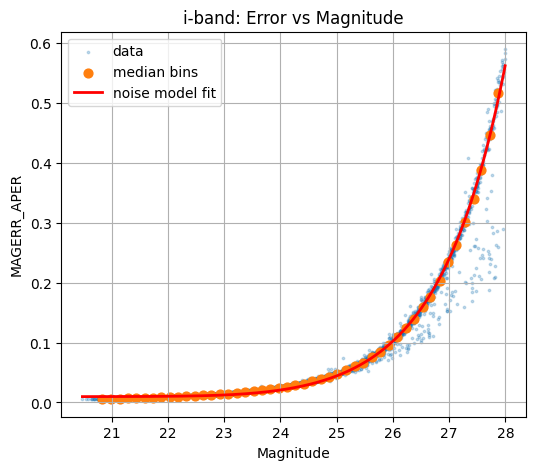


z-band fit parameters
sigma0 = 0.007821160467076942
a = 1.8877015041858818e-11
b = 0.8698360723367735


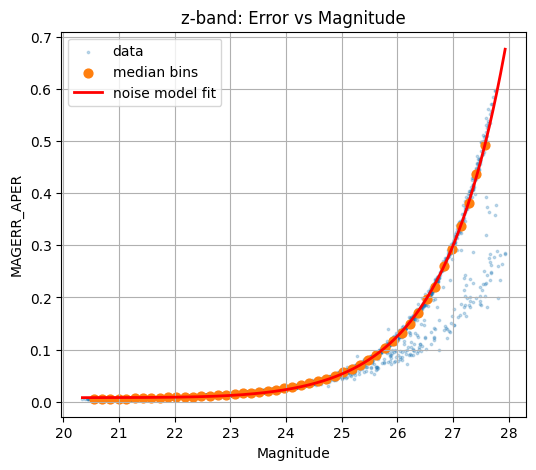


y-band fit parameters
sigma0 = 0.006884815088052062
a = 1.6813411598661068e-10
b = 0.8867536013088286


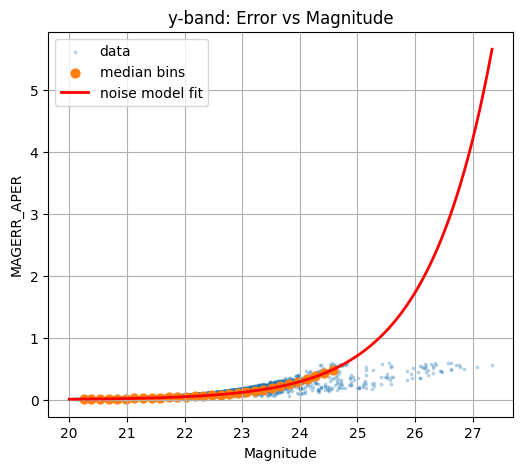

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astropy.coordinates import SkyCoord
import astropy.units as u


# --------------------------------------------------
# FILES
# --------------------------------------------------

i_file = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Y_I_CDFS.cat"
z_file = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Y_Z_CDFS.cat"
y_file = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Y_Y_CDFS.cat"


# --------------------------------------------------
# COLUMN NAMES
# --------------------------------------------------

colnames = [
    "ID","X","Y","RA","DEC",
    "MAG_APER","MAGERR_APER",
    "MAG_AUTO","MAGERR_AUTO","FLAGS","ISOAREA_IMAGE"
]

i_df = pd.read_csv(i_file, sep=r"\s+", comment="#", names=colnames)
z_df = pd.read_csv(z_file, sep=r"\s+", comment="#", names=colnames)
y_df = pd.read_csv(y_file, sep=r"\s+", comment="#", names=colnames)


# --------------------------------------------------
# ZEROPOINT CALIBRATION
# --------------------------------------------------

ZP_i, ZP_z, ZP_y = 31.349 , 31.509, 30.0807
zp_err_i, zp_err_z, zp_err_y = 0.003, 0.003, 0.0067




for df, zp, zp_err in zip(
        [i_df, z_df, y_df],
        [ZP_i, ZP_z, ZP_y],
        [zp_err_i, zp_err_z, zp_err_y]):

    df["MAG_APER_CAL"] = df["MAG_APER"] + zp
    df["MAGERR_APER_CAL"] = np.sqrt(df["MAGERR_APER"]**2 + zp_err**2)


# --------------------------------------------------
# CROSS MATCH
# --------------------------------------------------

y_coords = SkyCoord(y_df.RA.values*u.deg, y_df.DEC.values*u.deg)
z_coords = SkyCoord(z_df.RA.values*u.deg, z_df.DEC.values*u.deg)
i_coords = SkyCoord(i_df.RA.values*u.deg, i_df.DEC.values*u.deg)

idx_z, sep_z, _ = y_coords.match_to_catalog_sky(z_coords)
idx_i, sep_i, _ = y_coords.match_to_catalog_sky(i_coords)

match_radius = 1.0  # arcsec

z_match = sep_z.arcsec < match_radius
i_match = sep_i.arcsec < match_radius


# --------------------------------------------------
# ALIGN MAGNITUDES
# --------------------------------------------------

def align_mag_err(n, df, idx, mask):

    mag = np.full(n, np.nan)
    err = np.full(n, np.nan)

    mag[mask] = df.MAG_APER_CAL.values[idx[mask]]
    err[mask] = df.MAGERR_APER_CAL.values[idx[mask]]

    return mag, err


y_mag = y_df.MAG_APER_CAL.values
y_err = y_df.MAGERR_APER_CAL.values

z_mag, z_err = align_mag_err(len(y_mag), z_df, idx_z, z_match)
i_mag, i_err = align_mag_err(len(y_mag), i_df, idx_i, i_match)


# --------------------------------------------------
# KEEP TRIPLE MATCHES
# --------------------------------------------------

mask = (~np.isnan(y_mag)) & (~np.isnan(z_mag)) & (~np.isnan(i_mag))

y_mag, y_err = y_mag[mask], y_err[mask]
z_mag, z_err = z_mag[mask], z_err[mask]
i_mag, i_err = i_mag[mask], i_err[mask]


# --------------------------------------------------
# SNR FUNCTION
# --------------------------------------------------

def calculate_snr(mag_err):
    return (2.5 / np.log(10)) / mag_err


# --------------------------------------------------
# PHOTOMETRIC ERROR MODEL
# --------------------------------------------------

def mag_error_model(m, sigma0, a, b):
    return np.sqrt(sigma0**2 + (a*np.exp(b*m))**2)


# --------------------------------------------------
# FIT FUNCTION
# --------------------------------------------------

def fit_mag_err(mag, err, bandname):

    valid = np.isfinite(mag) & np.isfinite(err)
    mag = mag[valid]
    err = err[valid]

    good = (
        (mag > 20) &
        (mag < 28) &
        (err > 0.002) &
        (err < 0.6)
    )

    mag = mag[good]
    err = err[good]

    order = np.argsort(mag)
    mag = mag[order]
    err = err[order]

    # -----------------------------------
    # BIN DATA
    # -----------------------------------

    bins = np.arange(20, 28, 0.15)
    digitized = np.digitize(mag, bins)

    bin_mag = []
    bin_err = []

    for i in range(1, len(bins)):

        m = mag[digitized == i]
        e = err[digitized == i]

        if len(m) > 20:

            bin_mag.append(np.median(m))
            bin_err.append(np.median(e))

    bin_mag = np.array(bin_mag)
    bin_err = np.array(bin_err)

    # -----------------------------------
    # FIT MODEL
    # -----------------------------------

    try:

        popt, _ = curve_fit(
            mag_error_model,
            bin_mag,
            bin_err,
            p0=[0.01, 1e-7, 0.5],
            bounds=([0, 1e-12, 0.01], [0.1, 1, 5]),
            maxfev=50000
        )

    except RuntimeError:

        print(f"{bandname} fit failed — using exponential fallback")

        log_err = np.log(bin_err)
        coeff = np.polyfit(bin_mag, log_err, 1)

        b = coeff[0]
        a = np.exp(coeff[1])

        popt = [0.01, a, b]

    sigma0, a_fit, b_fit = popt

    print(f"\n{bandname} fit parameters")
    print("sigma0 =", sigma0)
    print("a =", a_fit)
    print("b =", b_fit)

    # -----------------------------------
    # SMOOTH CURVE
    # -----------------------------------

    x_fine = np.linspace(mag.min(), mag.max(), 1000)
    y_fit = mag_error_model(x_fine, sigma0, a_fit, b_fit)

    # -----------------------------------
    # PLOT
    # -----------------------------------

    plt.figure(figsize=(6,5))

    plt.scatter(mag, err, s=3, alpha=0.25, label="data")
    plt.scatter(bin_mag, bin_err, s=40, label="median bins")

    plt.plot(x_fine, y_fit, color="red", lw=2, label="noise model fit")

    plt.xlabel("Magnitude")
    plt.ylabel("MAGERR_APER")
    plt.title(f"{bandname}: Error vs Magnitude")

    plt.grid(True)
    plt.legend()

    plt.show()

    return popt


# --------------------------------------------------
# RUN FITS
# --------------------------------------------------

popt_i = fit_mag_err(i_mag, i_err, "i-band")
popt_z = fit_mag_err(z_mag, z_err, "z-band")
popt_y = fit_mag_err(y_mag, y_err, "y-band")

In [45]:
def degrade_band_full(original_df, mag_cal, err_cal, popt, bandname, output_path):

    print(f"\nDegrading {bandname}...")

    degraded_df = original_df.copy().reset_index(drop=True)

    # choose zeropoint
    if bandname == "i-band":
        ZP_use = ZP_i
        zp_err_use = zp_err_i

    elif bandname == "z-band":
        ZP_use = ZP_z
        zp_err_use = zp_err_z

    elif bandname == "y-band":
        ZP_use = ZP_y
        zp_err_use = zp_err_y

    else:
        raise ValueError("Band must be i-band, z-band, or y-band.")


    sigma0, a, b = popt


    # ----------------------------------
    # expected error from fitted model
    # ----------------------------------

    sigma_degraded = mag_error_model(mag_cal, sigma0, a, b)

    sigma_degraded[~np.isfinite(sigma_degraded)] = 0
    sigma_degraded[sigma_degraded < 0] = 0


    # ----------------------------------
    # extra noise needed
    # ----------------------------------

    sigma_extra_sq = sigma_degraded**2 - err_cal**2
    sigma_extra_sq[~np.isfinite(sigma_extra_sq)] = 0
    sigma_extra_sq[sigma_extra_sq < 0] = 0

    sigma_extra = np.sqrt(sigma_extra_sq)


    # ----------------------------------
    # degrade magnitudes
    # ----------------------------------

    mag_cal_degraded = np.random.normal(
        loc=mag_cal,
        scale=sigma_extra
    )


    # ----------------------------------
    # convert back to instrumental mags
    # ----------------------------------

    mag_aper_degraded = mag_cal_degraded - ZP_use


    # ----------------------------------
    # compute instrumental error
    # ----------------------------------

    sigma_inst_sq = sigma_degraded**2 - zp_err_use**2
    sigma_inst_sq[~np.isfinite(sigma_inst_sq)] = 0
    sigma_inst_sq[sigma_inst_sq < 0] = 0

    sigma_inst = np.sqrt(sigma_inst_sq)


    degraded_df["MAG_APER"] = mag_aper_degraded
    degraded_df["MAGERR_APER"] = sigma_inst


    degraded_df.to_csv(
        output_path,
        sep=" ",
        index=False,
        header=False
    )


    print(f"{bandname} degraded catalog saved to:")
    print(output_path)

    return degraded_df

In [46]:
degrade_band_full(
    i_df,
    i_df["MAG_APER_CAL"].values,
    i_df["MAGERR_APER_CAL"].values,
    popt_i,
    "i-band",
    "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_I_degraded.cat"
)

degrade_band_full(
    z_df,
    z_df["MAG_APER_CAL"].values,
    z_df["MAGERR_APER_CAL"].values,
    popt_z,
    "z-band",
    "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Z_degraded.cat"
)

degrade_band_full(
    y_df,
    y_df["MAG_APER_CAL"].values,
    y_df["MAGERR_APER_CAL"].values,
    popt_y,
    "y-band",
    "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Y_degraded.cat"
)


Degrading i-band...
i-band degraded catalog saved to:
/Users/aishwarya/Desktop/new_cdfs/cat/LBG_I_degraded.cat

Degrading z-band...
z-band degraded catalog saved to:
/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Z_degraded.cat

Degrading y-band...
y-band degraded catalog saved to:
/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Y_degraded.cat


,ID,X,Y,RA,DEC,MAG_APER,MAGERR_APER,MAG_AUTO,MAGERR_AUTO,FLAGS,ISOAREA_IMAGE,MAG_APER_CAL,MAGERR_APER_CAL
0,1,9332.4502,76.7015,53.025135,-29.012737,-6.300808e+00,2.447248e-01,-14.0240,0.0031,3,1506,23.7931,0.103118
1,2,10925.9795,55.3009,52.888512,-29.014620,-7.891700e+00,5.902920e-02,-10.9892,0.0235,3,44,22.1890,0.080081
2,3,9393.6172,134.6592,53.019877,-29.008406,-1.047630e+01,6.171053e-03,-16.2242,0.0018,19,21995,19.6044,0.012120
3,4,9496.7520,9.0190,53.011064,-29.017846,-9.180300e+00,1.888810e-02,-12.7505,0.0066,27,849,20.9004,0.027625
4,5,9544.8145,9.9681,53.006943,-29.017785,-8.677100e+00,2.944915e-02,-10.9782,0.0194,19,188,21.4036,0.041248
...,...,...,...,...,...,...,...,...,...,...,...,...,...
109368,109369,18944.9648,25136.0137,52.209297,-27.133310,-6.998900e+00,1.302479e-01,-6.9951,0.1633,0,8,23.0818,0.131371
109369,109370,18941.1914,25142.6621,52.209617,-27.132812,-6.896107e+00,1.450112e-01,-7.0264,0.1479,1,4,23.2029,0.144356
109370,109371,17260.5059,25154.4941,52.351220,-27.132328,-7.348822e+00,9.445718e-02,-8.3800,0.0617,3,7,22.7194,0.093540
109371,109372,10803.0000,25203.9844,52.895284,-27.128844,9.872010e+38,8.633913e+39,-4.4871,0.4183,1,0,129.0807,99.000000


In [13]:
from astropy.io import fits
import numpy as np

data = fits.getdata("/Users/aishwarya/Desktop/new_cdfs/Bkg/BG_Y_Y_CDFS.fits")

print("Min:", np.nanmin(data))
print("Max:", np.nanmax(data))
print("Median:", np.nanmedian(data))
print("Std:", np.nanstd(data))

Min: -1e+30
Max: 14287.08
Median: -4.0768833
Std: inf


/Users/aishwarya/.local/share/mamba/envs/astroenv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1872: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)
